In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

### Load Cleaned Dataset

In [6]:
df = pd.read_csv("boston_cleaned_eda.csv")
df

,ID,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,2,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,4,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
3,5,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
4,7,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,12.43,22.9
...,...,...,...,...,...,...,...,...,...,...,...,...
328,500,9.69,0,0.585,5.569,73.5,2.3999,6,391,19.2,15.10,17.5
329,502,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
330,503,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
331,504,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9


### Define Feature(X) and Target(House Price)

In [8]:
X = df.drop("medv", axis=1)
Y = df["medv"]

### Train Test Split

In [10]:
X_train,X_test,Y_train,Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(266, 11)
(67, 11)


### Build Random Forest Model

In [11]:
RF=RandomForestRegressor(n_estimators=100, random_state=42)

### Tarain The Model

In [13]:
RF.fit(X_train, Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Prediction

In [14]:
Y_pred = RF.predict(X_test)

### Evaluate Model

In [16]:
mae = mean_absolute_error(Y_test, Y_pred)
print("MAE",mae)

MAE 2.169955223880595


In [17]:
mse = mean_squared_error(Y_test, Y_pred)
print("MSE", mse)

MSE 8.504203955223874


In [23]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 2.9161968306724213


In [27]:
r2 = r2_score(Y_test,Y_pred)
print("R2 Score:", r2)

R2 Score: 0.9055071469193502


### Feature IMP

In [29]:
importance = RF.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

    Feature  Importance
10    lstat    0.417909
4        rm    0.392616
6       dis    0.082660
0        ID    0.022234
5       age    0.018765
3       nox    0.017665
7       rad    0.013597
8       tax    0.013279
9   ptratio    0.012580
1     indus    0.006648
2      chas    0.002047


### Visulize Feature IMP

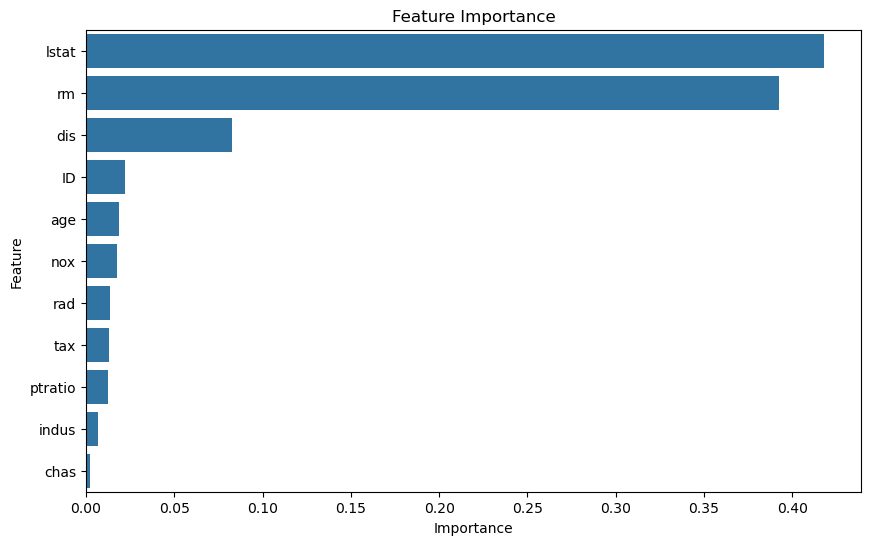

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

### Comapire Actual and Predicted Values

In [32]:
comparison = pd.DataFrame({
    "Actual": Y_test,
    "Predicted": Y_pred
})

comparison.head(10)

,Actual,Predicted
25,24.7,24.077
309,19.6,20.800
73,19.8,18.616
195,27.9,28.099
57,23.9,21.756
296,13.5,18.026
281,11.7,17.811
180,30.7,27.437
211,17.8,18.770
197,27.1,26.795


## Scatter Plot(Actual vs Predicted)

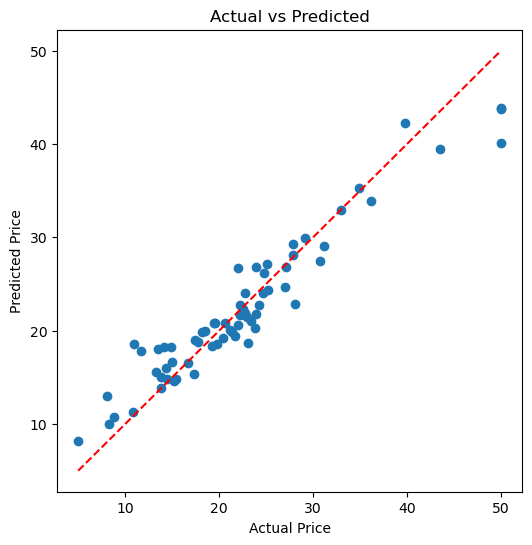

In [34]:
plt.figure(figsize=(6,6))

plt.scatter(Y_test, Y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.plot(
    [Y.min(), Y.max()],
    [Y.min(), Y.max()],
    'r--'
)

plt.show()

## Hyperperameter Tuning Using GridSearchCV 

### Define The Parameter Grid

In [37]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

### Apply grid Search

In [39]:
grid_search = GridSearchCV(
    estimator=RF,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

### Train The Grid Search

In [40]:
grid_search.fit(X_train, Y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


### View The Best Parameter

In [41]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


### Best Cross Validation

In [42]:
print("Best Cross Validation Score:", grid_search.best_score_)

Best Cross Validation Score: 0.8388624281491627


### Best Model

In [43]:
best_rf = grid_search.best_estimator_

### Predict With The Tuned Model

In [44]:
Y_pred = best_rf.predict(X_test)

### Evaluate The Tuned Model

In [45]:
print("MAE :", mean_absolute_error(Y_test, Y_pred))

print("MSE :", mean_squared_error(Y_test, Y_pred))

print("RMSE:", np.sqrt(mean_squared_error(Y_test, Y_pred)))

print("R² Score:", r2_score(Y_test, Y_pred))

MAE : 2.1416567164179128
MSE : 8.309403902155875
RMSE: 2.882603667200171
R² Score: 0.9076716308488955


### Comapare Actual vs Predicted 

In [47]:
comparison = pd.DataFrame({
    "Actual": Y_test,
    "Predicted": Y_pred
})

comparison.head(10)

,Actual,Predicted
25,24.7,24.112333
309,19.6,20.639667
73,19.8,18.675333
195,27.9,28.040333
57,23.9,21.879667
296,13.5,18.512000
281,11.7,17.689333
180,30.7,27.686333
211,17.8,19.294000
197,27.1,26.606333


### Feature IMP(Best Model) 

In [48]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

    Feature  Importance
10    lstat    0.409712
4        rm    0.400327
6       dis    0.087713
0        ID    0.022545
5       age    0.018396
3       nox    0.016106
8       tax    0.014610
9   ptratio    0.011505
7       rad    0.009516
1     indus    0.007800
2      chas    0.001772


### Plot Feature Importance

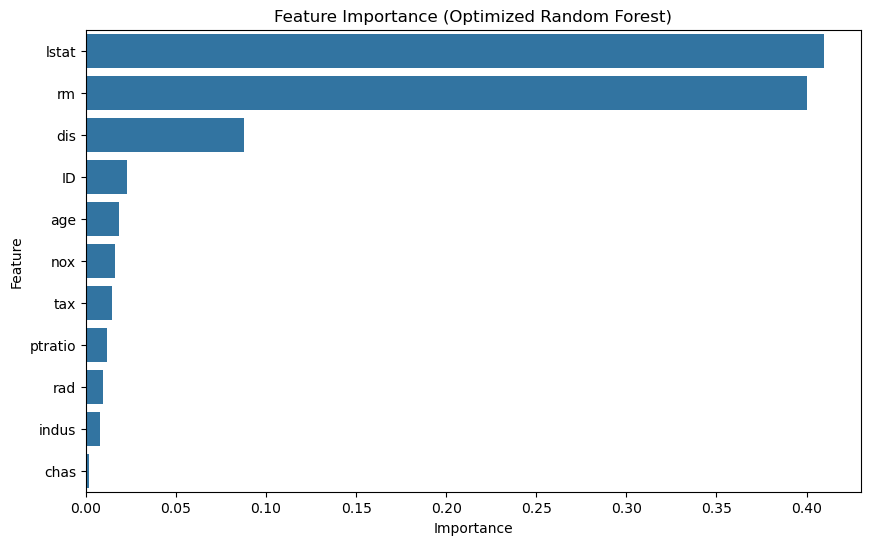

In [49]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (Optimized Random Forest)")
plt.show()

### Save The Model (Import joblib)

In [51]:
joblib.dump(best_rf, "random_forest_model.pkl")

['random_forest_model.pkl']

### Load The Saved Model

In [52]:
loaded_model = joblib.load("random_forest_model.pkl")

### Make Prediction

In [53]:
predictions = loaded_model.predict(X_test)

print(predictions[:10])

[24.11233333 20.63966667 18.67533333 28.04033333 21.87966667 18.512
 17.68933333 27.68633333 19.294      26.60633333]


### Verify The Loaded Model 

In [54]:
print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


### Save The Feature Columns

In [55]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

### For Load Them Later

In [56]:
feature_columns = joblib.load("feature_columns.pkl")
print(feature_columns)

['ID', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'lstat']
